In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Settings
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# load both datasets

df1 = pd.read_csv("data/Unemployment in India.csv")
df2 = pd.read_csv("data/Unemployment_Rate_upto_11_2020.csv")

In [3]:
# inspect Datasets

print("Data 1:",df1.shape)
print("Data 2:",df2.shape)

display(df1.head())
display(df2.head())

Data 1: (768, 7)
Data 2: (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [4]:
print(df1.columns)
print(df2.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [5]:
# Basic infomations
print("df1 infomation:/n",df1.info())
print("df2 infomation:/n",df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
df1 infomation:/n None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  -

In [6]:
# clean Column Names

def clean_columns(df):

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
        .str.replace("%", "pct", regex=False)
    )

    return df

df1 = clean_columns(df1)
df2 = clean_columns(df2)

In [7]:
print(df1.columns)
print(df2.columns)

Index(['region', 'date', 'frequency', 'estimated_unemployment_rate_pct',
       'estimated_employed', 'estimated_labour_participation_rate_pct',
       'area'],
      dtype='object')
Index(['region', 'date', 'frequency', 'estimated_unemployment_rate_pct',
       'estimated_employed', 'estimated_labour_participation_rate_pct',
       'region.1', 'longitude', 'latitude'],
      dtype='object')


In [8]:
# convert date

df1["date"] = pd.to_datetime(df1["date"])
df2["date"] = pd.to_datetime(df2["date"])

C:\Users\hp\AppData\Local\Temp\ipykernel_17976\2378636006.py:3: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1["date"] = pd.to_datetime(df1["date"])
C:\Users\hp\AppData\Local\Temp\ipykernel_17976\2378636006.py:4: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df2["date"] = pd.to_datetime(df2["date"])


In [9]:
# verify

df1.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   region                                   740 non-null    object        
 1   date                                     740 non-null    datetime64[ns]
 2   frequency                                740 non-null    object        
 3   estimated_unemployment_rate_pct          740 non-null    float64       
 4   estimated_employed                       740 non-null    float64       
 5   estimated_labour_participation_rate_pct  740 non-null    float64       
 6   area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                

In [10]:
# percentage missing df1
missing_df1 = pd.DataFrame({
    'Missing Count': df1.isnull().sum(),
    'Missing %': round(df1.isnull().mean() * 100, 2)
})

missing_df1.sort_values('Missing %', ascending=False)


,Missing Count,Missing %
region,28,3.65
date,28,3.65
frequency,28,3.65
estimated_unemployment_rate_pct,28,3.65
estimated_employed,28,3.65
estimated_labour_participation_rate_pct,28,3.65
area,28,3.65


In [11]:
df1[df1.isnull().all(axis=1)]

,region,date,frequency,estimated_unemployment_rate_pct,estimated_employed,estimated_labour_participation_rate_pct,area
359,NaN,NaT,NaN,NaN,NaN,NaN,NaN
360,NaN,NaT,NaN,NaN,NaN,NaN,NaN
361,NaN,NaT,NaN,NaN,NaN,NaN,NaN
362,NaN,NaT,NaN,NaN,NaN,NaN,NaN
363,NaN,NaT,NaN,NaN,NaN,NaN,NaN
364,NaN,NaT,NaN,NaN,NaN,NaN,NaN
365,NaN,NaT,NaN,NaN,NaN,NaN,NaN
366,NaN,NaT,NaN,NaN,NaN,NaN,NaN
367,NaN,NaT,NaN,NaN,NaN,NaN,NaN
368,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [12]:
df1[df1.isnull().all(axis=1)].shape

(28, 7)

In [13]:
# percentage missing df2

missing_df2 = pd.DataFrame({
    'Missing Count': df2.isnull().sum(),
    'Missing %': round(df2.isnull().mean() * 100, 2)
})

missing_df2.sort_values('Missing %', ascending=False)

,Missing Count,Missing %
region,0,0.0
date,0,0.0
frequency,0,0.0
estimated_unemployment_rate_pct,0,0.0
estimated_employed,0,0.0
estimated_labour_participation_rate_pct,0,0.0
region.1,0,0.0
longitude,0,0.0
latitude,0,0.0


In [14]:
# check for duplicate

print("DF1 duplicates:", df1.duplicated().sum())
print("DF2 duplicates:", df2.duplicated().sum())

DF1 duplicates: 27
DF2 duplicates: 0


In [15]:
duplicates = df1[df1.duplicated()]

duplicates.head()

,region,date,frequency,estimated_unemployment_rate_pct,estimated_employed,estimated_labour_participation_rate_pct,area
360,NaN,NaT,NaN,NaN,NaN,NaN,NaN
361,NaN,NaT,NaN,NaN,NaN,NaN,NaN
362,NaN,NaT,NaN,NaN,NaN,NaN,NaN
363,NaN,NaT,NaN,NaN,NaN,NaN,NaN
364,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [16]:
df1 = df1.dropna(how='all')

In [17]:
print(df1.shape)
print(df1.duplicated().sum())

(740, 7)
0


In [18]:
print(df1.duplicated().sum())

0


In [19]:
df1.isnull().sum()

region                                     0
date                                       0
frequency                                  0
estimated_unemployment_rate_pct            0
estimated_employed                         0
estimated_labour_participation_rate_pct    0
area                                       0
dtype: int64

In [20]:
# unique states
print(df1["region"].nunique())
print(df2["region"].nunique())

28
27


In [21]:
# investigate missing state
set(df1["region"].unique()) - set(df2["region"].unique())

{'Chandigarh'}

In [22]:
set(df2["region"].unique()) - set(df1["region"].unique())

set()

In [23]:
# frequency count
df1["frequency"] = df1["frequency"].str.strip()

df1["frequency"].value_counts()


frequency
Monthly    740
Name: count, dtype: int64

In [24]:
df2["frequency"] = df2["frequency"].str.strip()

df2["frequency"].value_counts()

frequency
M    267
Name: count, dtype: int64

In [25]:
# standardize
df1.columns = [
    col.strip()
       .replace(" (%)", "")
       .replace(" ", "_")
       .title()
    for col in df1.columns
]

df2.columns = [
    col.strip()
       .replace(" (%)", "")
       .replace(" ", "_")
       .title()
    for col in df2.columns
]

In [26]:
print(df1.columns)
print(df2.columns)


Index(['Region', 'Date', 'Frequency', 'Estimated_Unemployment_Rate_Pct',
       'Estimated_Employed', 'Estimated_Labour_Participation_Rate_Pct',
       'Area'],
      dtype='object')
Index(['Region', 'Date', 'Frequency', 'Estimated_Unemployment_Rate_Pct',
       'Estimated_Employed', 'Estimated_Labour_Participation_Rate_Pct',
       'Region.1', 'Longitude', 'Latitude'],
      dtype='object')


In [27]:
missing_geo = ['Chandigarh']

In [28]:
new_row = {
    'region': 'Chandigarh',
    'region_1': 'North',
    'longitude': 76.7794,
    'latitude': 30.7333
}

Geographic metadata for Chandigarh was unavailable in the supplementary dataset and was manually incorporated from publicly available geographic reference data to preserve complete state-level coverage.

In [29]:
print(df1["Date"].min())
print(df1["Date"].max())

print(df2["Date"].min())
print(df2["Date"].max())

2019-05-31 00:00:00
2020-06-30 00:00:00
2020-01-31 00:00:00
2020-10-31 00:00:00


In [30]:
df2.head()

,Region,Date,Frequency,Estimated_Unemployment_Rate_Pct,Estimated_Employed,Estimated_Labour_Participation_Rate_Pct,Region.1,Longitude,Latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


In [31]:
geo_lookup = (
    df2[
        ["Region", "Region.1", "Longitude", "Latitude"]
    ]
    .drop_duplicates()
)

In [32]:
# Rename
geo_lookup = geo_lookup.rename(
    columns={"Region.1": "zone"}
)

In [33]:
# Add Chandigarh

chandigarh = pd.DataFrame({
    "Region": ["Chandigarh"],
    "zone": ["North"],
    "Longitude": [76.7794],
    "Latitude": [30.7333]
})

In [34]:
# Append
geo_lookup = pd.concat(
    [geo_lookup, chandigarh],
    ignore_index=True
)

In [35]:
# merge
df = df1.merge(
    geo_lookup,
    on="Region",
    how="left"
)

In [36]:
# validate
print(df.shape)
display(df.head())
print(df.columns)

(740, 10)


,Region,Date,Frequency,Estimated_Unemployment_Rate_Pct,Estimated_Employed,Estimated_Labour_Participation_Rate_Pct,Area,zone,Longitude,Latitude
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,South,15.9129,79.74
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,South,15.9129,79.74
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,South,15.9129,79.74
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,South,15.9129,79.74
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,South,15.9129,79.74


Index(['Region', 'Date', 'Frequency', 'Estimated_Unemployment_Rate_Pct',
       'Estimated_Employed', 'Estimated_Labour_Participation_Rate_Pct', 'Area',
       'zone', 'Longitude', 'Latitude'],
      dtype='object')


In [37]:
# check missing after merge
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated_Unemployment_Rate_Pct            0
Estimated_Employed                         0
Estimated_Labour_Participation_Rate_Pct    0
Area                                       0
zone                                       0
Longitude                                  0
Latitude                                   0
dtype: int64

In [38]:
df[df["Region"] == "Chandigarh"].head()

,Region,Date,Frequency,Estimated_Unemployment_Rate_Pct,Estimated_Employed,Estimated_Labour_Participation_Rate_Pct,Area,zone,Longitude,Latitude
401,Chandigarh,2019-05-31,Monthly,18.35,348042.0,44.89,Urban,North,76.7794,30.7333
402,Chandigarh,2019-06-30,Monthly,12.40,337145.0,40.44,Urban,North,76.7794,30.7333
403,Chandigarh,2019-07-31,Monthly,21.80,294379.0,39.47,Urban,North,76.7794,30.7333
404,Chandigarh,2019-08-31,Monthly,9.52,328282.0,37.95,Urban,North,76.7794,30.7333
405,Chandigarh,2019-09-30,Monthly,20.14,327239.0,42.77,Urban,North,76.7794,30.7333


In [39]:
# check for missing zone
df[df[["zone", "Longitude", "Latitude"]].isnull().any(axis=1)]["Region"].unique()

array([], dtype=object)

In [40]:
# create COVID flag
df["Covid_Period"] = np.where(
    df["Date"] < "2020-04-01",
    "Pre-COVID",
    "COVID Period"
)

In [41]:
# Visualization

# Geographic Information
df.groupby("zone")[
    "Estimated_Unemployment_Rate_Pct"
].mean()

zone
East         13.321429
North        15.388026
Northeast    12.385204
South         8.566084
West          7.991838
Name: Estimated_Unemployment_Rate_Pct, dtype: float64

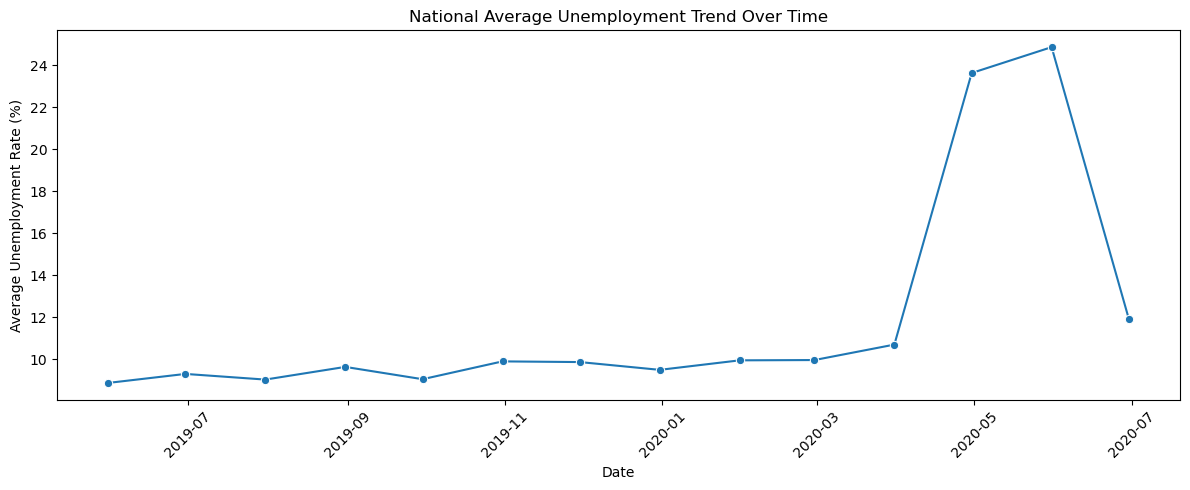

In [42]:
# 1. National Unemployment trend

national_trend = (
    df.groupby("Date")["Estimated_Unemployment_Rate_Pct"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))
sns.lineplot(
    data=national_trend,
    x="Date",
    y="Estimated_Unemployment_Rate_Pct",
    marker="o"
)

plt.title("National Average Unemployment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

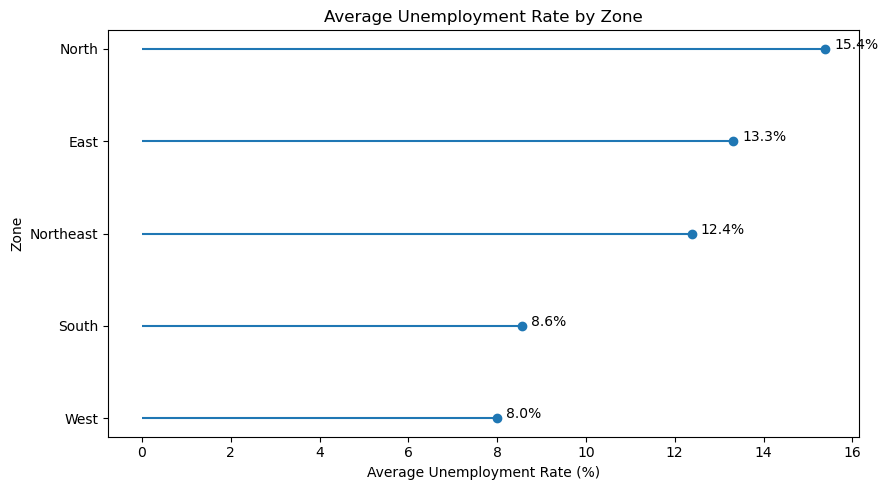

In [43]:
#2. Zone comparison

zone_avg = (
    df.groupby("zone")["Estimated_Unemployment_Rate_Pct"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9,5))

plt.hlines(
    y=zone_avg.index,
    xmin=0,
    xmax=zone_avg.values
)

plt.plot(
    zone_avg.values,
    zone_avg.index,
    "o"
)

for i, value in enumerate(zone_avg.values):
    plt.text(value + 0.2, i, f"{value:.1f}%")

plt.title("Average Unemployment Rate by Zone")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Zone")
plt.tight_layout()
plt.show()

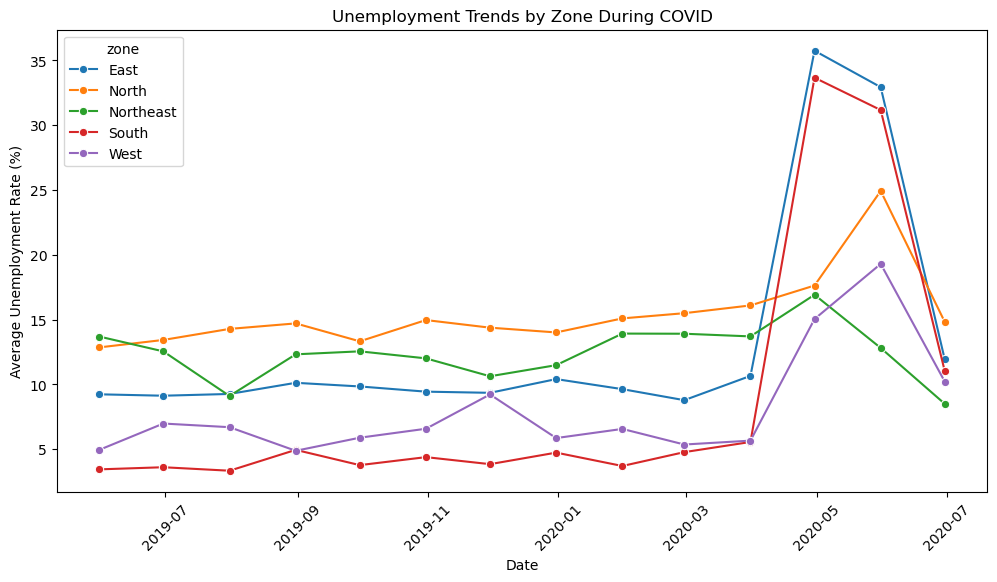

In [44]:
#3. Average unemployment by zone

zone_trend = (
    df.groupby(["Date","zone"])
      ["Estimated_Unemployment_Rate_Pct"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=zone_trend,
    x="Date",
    y="Estimated_Unemployment_Rate_Pct",
    hue="zone",
    marker="o"
)

plt.title("Unemployment Trends by Zone During COVID")
plt.ylabel("Average Unemployment Rate (%)")
plt.xlabel("Date")

plt.xticks(rotation=45)

plt.show()

Unemployment remained relatively stable throughout 2019 and early 2020 before experiencing a sharp increase during the onset of COVID-19. Average unemployment more than doubled during the pandemic period, rising by 110.03%, with statistical testing confirming that the increase was highly significant (p < 0.001).

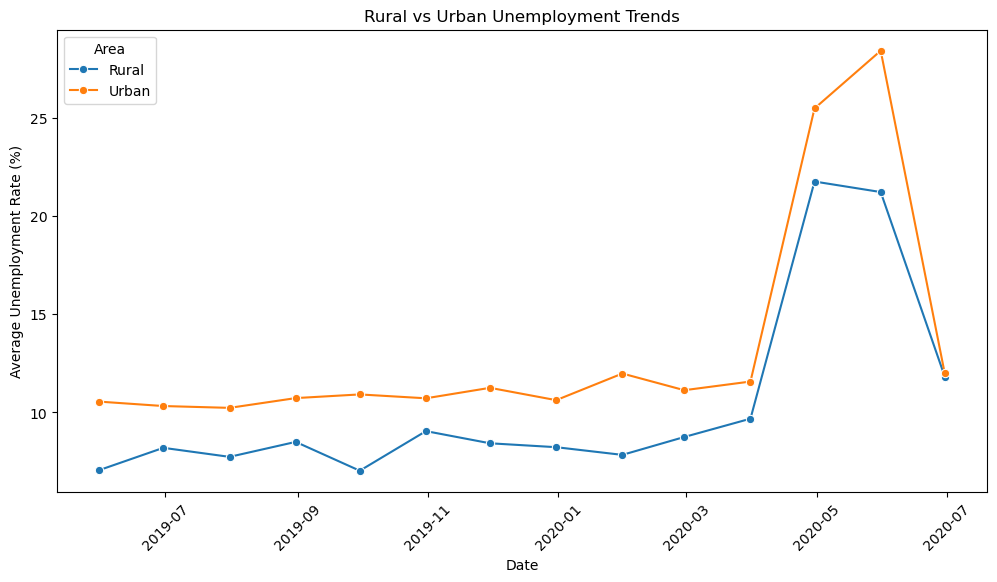

In [45]:
#4. Rural vs Urban during COVID
area_trend = (
    df.groupby(["Date","Area"])
      ["Estimated_Unemployment_Rate_Pct"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=area_trend,
    x="Date",
    y="Estimated_Unemployment_Rate_Pct",
    hue="Area",
    marker="o"
)

plt.title("Rural vs Urban Unemployment Trends")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

Urban areas consistently experienced higher unemployment than rural areas and suffered a larger spike during the COVID period.

In [46]:
#5. Top 10 regions by average unemployment

top10 = (
    df.groupby("Region")["Estimated_Unemployment_Rate_Pct"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

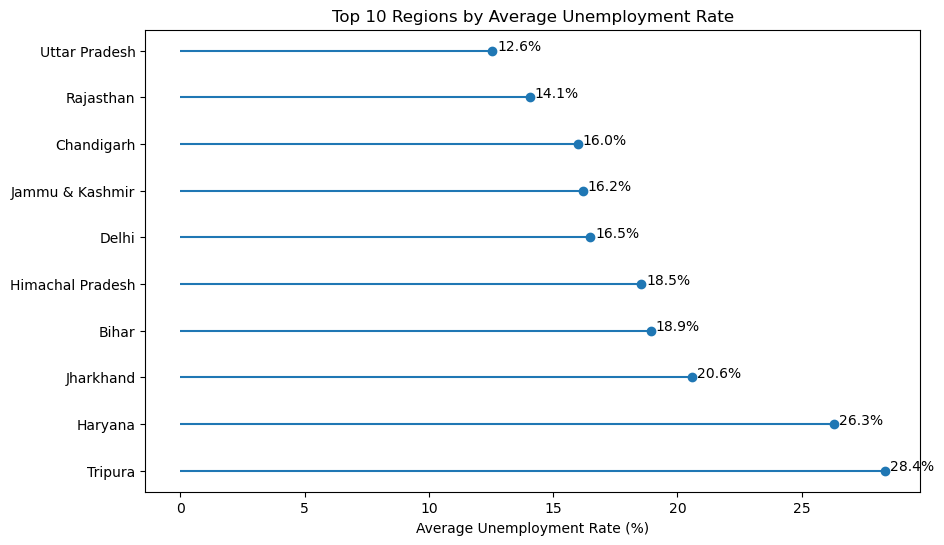

In [47]:
plt.figure(figsize=(10,6))

plt.hlines(
    y=top10["Region"],
    xmin=0,
    xmax=top10["Estimated_Unemployment_Rate_Pct"]
)

plt.plot(
    top10["Estimated_Unemployment_Rate_Pct"],
    top10["Region"],
    "o"
)

for i, value in enumerate(top10["Estimated_Unemployment_Rate_Pct"]):
    plt.text(
        value + 0.2,
        i,
        f"{value:.1f}%"
    )

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")

plt.show()

In [48]:
print(df["Date"].min())
print(df["Date"].max())

2019-05-31 00:00:00
2020-06-30 00:00:00


In [49]:
#6. Labour participation Analysis
df[
    [
        "Estimated_Unemployment_Rate_Pct",
        "Estimated_Labour_Participation_Rate_Pct"
    ]
].corr()

,Estimated_Unemployment_Rate_Pct,Estimated_Labour_Participation_Rate_Pct
Estimated_Unemployment_Rate_Pct,1.000000,0.002558
Estimated_Labour_Participation_Rate_Pct,0.002558,1.000000


<Axes: xlabel='Estimated_Labour_Participation_Rate_Pct', ylabel='Estimated_Unemployment_Rate_Pct'>

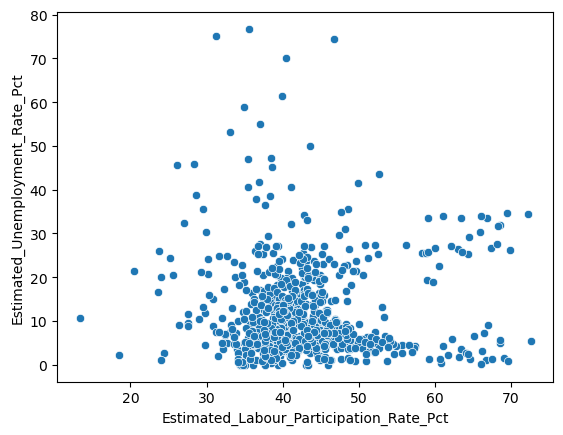

In [50]:
sns.scatterplot(
    data=df,
    x="Estimated_Labour_Participation_Rate_Pct",
    y="Estimated_Unemployment_Rate_Pct"
)

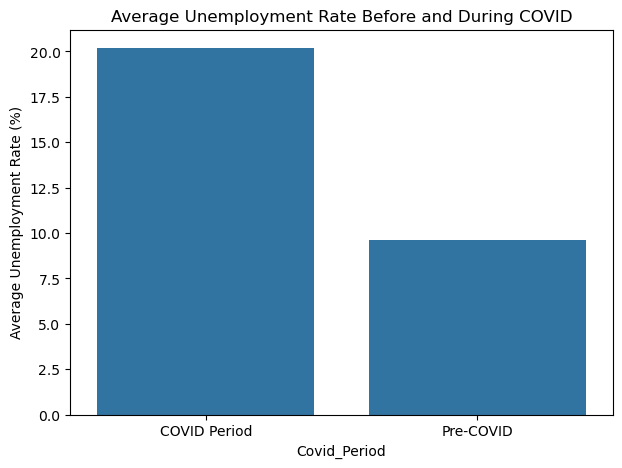

In [51]:
#7. pre-COVID vs COVID

period_avg = (
    df.groupby("Covid_Period")
      ["Estimated_Unemployment_Rate_Pct"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(7,5))

sns.barplot(
    data=period_avg,
    x="Covid_Period",
    y="Estimated_Unemployment_Rate_Pct"
)

plt.title("Average Unemployment Rate Before and During COVID")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()


No strong linear association was observed between labour participation rates and unemployment rates during the study period.

In [52]:
df[
    [
        "Estimated_Employed",
        "Estimated_Unemployment_Rate_Pct"
    ]
].corr()

,Estimated_Employed,Estimated_Unemployment_Rate_Pct
Estimated_Employed,1.000000,-0.222876
Estimated_Unemployment_Rate_Pct,-0.222876,1.000000


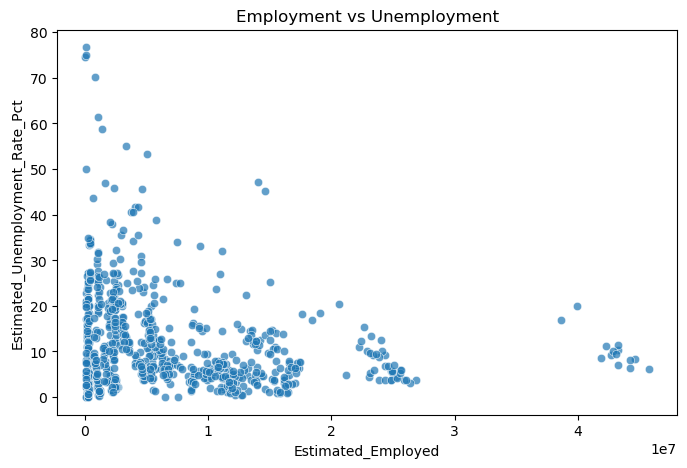

In [53]:
# 9. Employment and Unemployment

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Estimated_Employed",
    y="Estimated_Unemployment_Rate_Pct",
    alpha=0.7
)

plt.title("Employment vs Unemployment")
plt.show()

In [54]:
# COVID Summary Statistics

df["Covid_Period"] = np.where(
    df["Date"] < "2020-04-01",
    "Pre-COVID",
    "COVID Period"
)

In [55]:
covid_summary = (
    df.groupby("Covid_Period")
      ["Estimated_Unemployment_Rate_Pct"]
      .agg(
          Mean="mean",
          Median="median",
          Maximum="max",
          Minimum="min",
          Std="std"
      )
)

covid_summary

,Mean,Median,Maximum,Minimum,Std
Covid_Period,,,,,
COVID Period,20.194342,16.400,76.74,0.0,16.177736
Pre-COVID,9.614864,7.225,34.69,0.0,7.372715


In [56]:
# Percentage Increase Due To COVID
pre = df[
    df["Covid_Period"] == "Pre-COVID"
]["Estimated_Unemployment_Rate_Pct"].mean()

covid = df[
    df["Covid_Period"] == "COVID Period"
]["Estimated_Unemployment_Rate_Pct"].mean()

increase = ((covid - pre) / pre) * 100

print(f"Increase: {increase:.2f}%")

Increase: 110.03%


The average unemployment rate increased from 9.61% before COVID-19 to 20.19% during the COVID period, representing a 110.03% increase. This indicates a substantial disruption to the Indian labour market following the onset of the pandemic.

In [57]:
# Regional Ranking During COVID
covid_regions = (
    df[df["Covid_Period"] == "COVID Period"]
    .groupby("Region")
    ["Estimated_Unemployment_Rate_Pct"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

covid_regions

Region
Puducherry       57.700000
Jharkhand        44.896667
Haryana          37.693333
Bihar            36.988333
Tamil Nadu       31.735000
Tripura          26.053333
Delhi            24.165000
Kerala           20.938333
Uttar Pradesh    19.561667
Karnataka        19.155000
Name: Estimated_Unemployment_Rate_Pct, dtype: float64

In [58]:
# Statistical Test
from scipy.stats import ttest_ind

pre_values = df[
    df["Covid_Period"] == "Pre-COVID"
]["Estimated_Unemployment_Rate_Pct"]

covid_values = df[
    df["Covid_Period"] == "COVID Period"
]["Estimated_Unemployment_Rate_Pct"]

t_stat, p_value = ttest_ind(
    pre_values,
    covid_values,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -7.854382867089279
P-value: 4.591576201532397e-13


The increase in unemployment observed during the COVID period is statistically significant and unlikely to have occurred by chance.

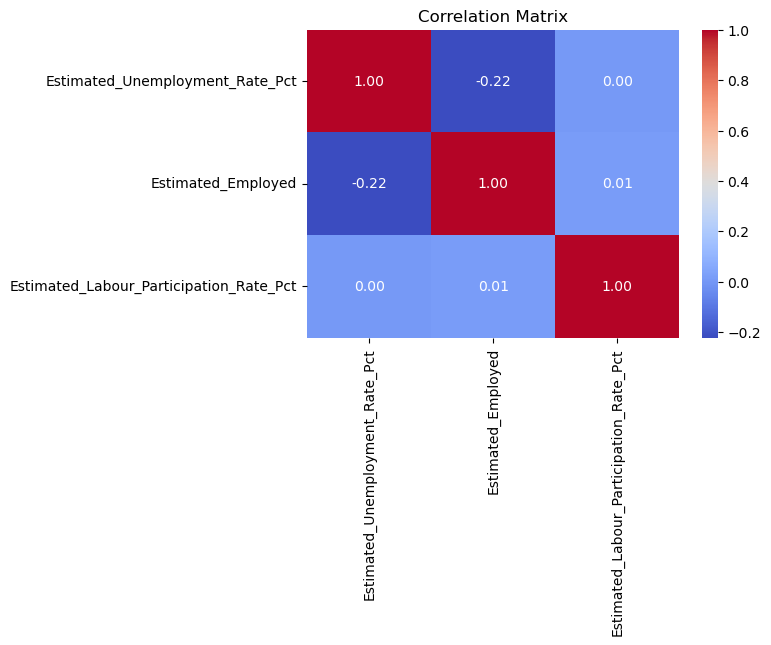

In [59]:
# Correlation Heatmap
num_cols = [
    "Estimated_Unemployment_Rate_Pct",
    "Estimated_Employed",
    "Estimated_Labour_Participation_Rate_Pct"
]

plt.figure(figsize=(6,4))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# ML and SHAP


In [60]:
# feature engineering
df_ml = df.copy()

#create month
df_ml["Month"] = df_ml["Date"].dt.month
df_ml["Quarter"] = df_ml["Date"].dt.quarter

In [61]:
df_ml[["Date","Month","Quarter"]].head()

,Date,Month,Quarter
0,2019-05-31,5,2
1,2019-06-30,6,2
2,2019-07-31,7,3
3,2019-08-31,8,3
4,2019-09-30,9,3


In [62]:
# Define Target
target = "Estimated_Unemployment_Rate_Pct"

In [63]:
#Select features
features = [
    "Estimated_Employed",
    "Estimated_Labour_Participation_Rate_Pct",
    "Region",
    "Area",
    "Covid_Period",
    "Month"
]

In [64]:
# Using One-Hot Encoder categories
X = pd.get_dummies(
    df_ml[features],
    drop_first=True
)

X.head()

,Estimated_Employed,Estimated_Labour_Participation_Rate_Pct,Month,Region_Assam,Region_Bihar,Region_Chandigarh,Region_Chhattisgarh,Region_Delhi,Region_Goa,Region_Gujarat,Region_Haryana,Region_Himachal Pradesh,Region_Jammu & Kashmir,Region_Jharkhand,Region_Karnataka,Region_Kerala,Region_Madhya Pradesh,Region_Maharashtra,Region_Meghalaya,Region_Odisha,Region_Puducherry,Region_Punjab,Region_Rajasthan,Region_Sikkim,Region_Tamil Nadu,Region_Telangana,Region_Tripura,Region_Uttar Pradesh,Region_Uttarakhand,Region_West Bengal,Area_Urban,Covid_Period_Pre-COVID
0,11999139.0,43.24,5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,11755881.0,42.05,6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,12086707.0,43.50,7,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,12285693.0,43.97,8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,12256762.0,44.68,9,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [65]:
# create y

y = df_ml[target]

In [66]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
# Baseline Model

import numpy as np
from sklearn.metrics import mean_absolute_error

baseline_pred = np.repeat(
    y_train.mean(),
    len(y_test)
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 8.377904492330169


In [68]:
# XGBoost Model
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [69]:
# Predictions
preds = model.predict(X_test)

In [70]:
# Evaluate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, preds)

rmse = mean_squared_error(
    y_test,
    preds
) ** 0.5

r2 = r2_score(
    y_test,
    preds
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 3.7517524444734724
RMSE: 6.432599122234274
R²: 0.7141940429841727


In [71]:
# Using SHAP

import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

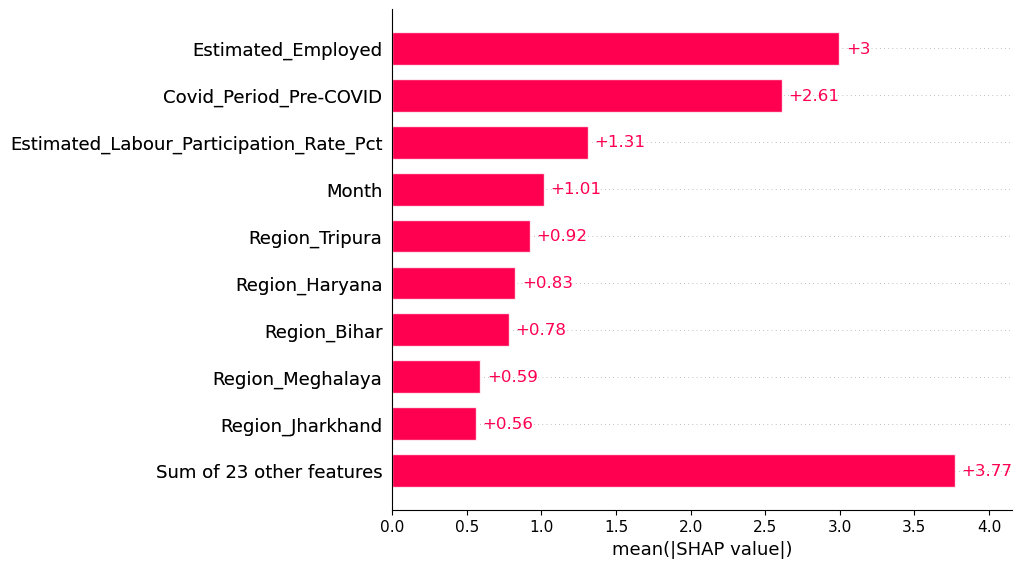

In [72]:
# Global Importance

shap.plots.bar(shap_values)

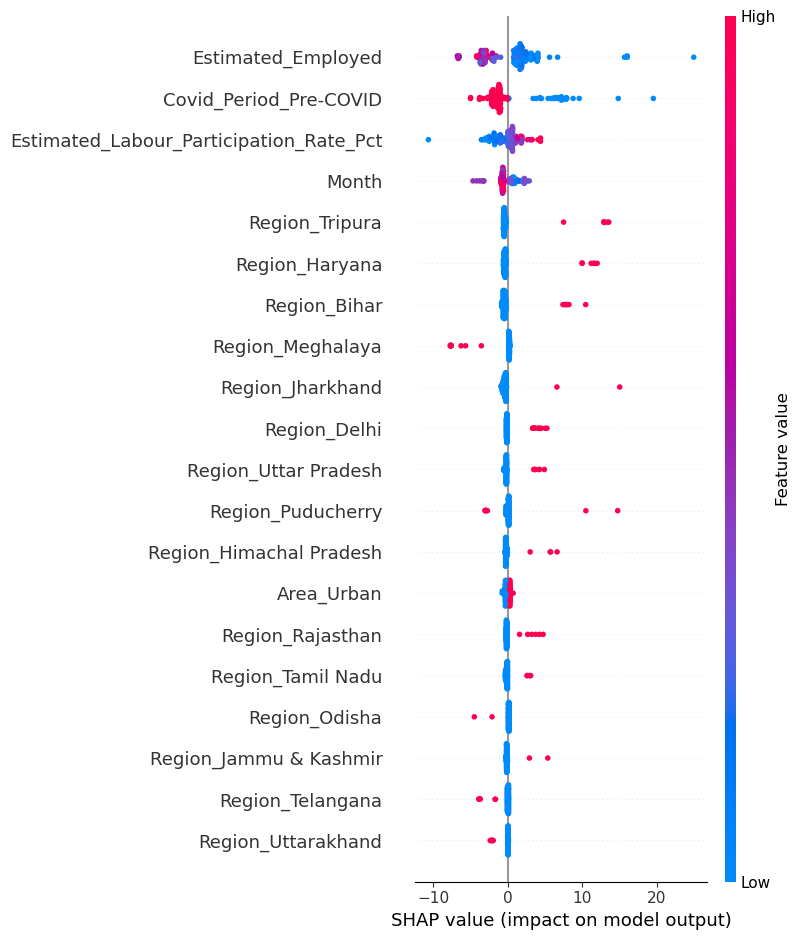

In [73]:
# Detailed Summary

shap.summary_plot(
    shap_values,
    X_test
)

Employment levels were the strongest predictor of unemployment.

COVID period was the second most influential factor.

Northern states and specific regions such as Tripura, Bihar and Jharkhand contributed significantly to unemployment variation.

 # STREAMLIT DASHBOARD

In [74]:
# Dashboard preparation
# Dataset 1: National Trend
national_trend = (
    df.groupby("Date")
      ["Estimated_Unemployment_Rate_Pct"]
      .mean()
      .reset_index()
)

national_trend.head()

,Date,Estimated_Unemployment_Rate_Pct
0,2019-05-31,8.874259
1,2019-06-30,9.303333
2,2019-07-31,9.033889
3,2019-08-31,9.637925
4,2019-09-30,9.051731


In [75]:
national_trend.to_csv(
    "national_trend.csv",
    index=False
)

In [76]:
# Dataset 2: Zone Trend
zone_trend = (
    df.groupby(["Date","zone"])
      ["Estimated_Unemployment_Rate_Pct"]
      .mean()
      .reset_index()
)

zone_trend.head()

,Date,zone,Estimated_Unemployment_Rate_Pct
0,2019-05-31,East,9.237500
1,2019-05-31,North,12.857647
2,2019-05-31,Northeast,13.694286
3,2019-05-31,South,3.446667
4,2019-05-31,West,4.951000


In [77]:
zone_trend.to_csv(
    "zone_trend.csv",
    index=False
)

In [79]:
# Dataset 3: Top Regions
top_regions = (
    df.groupby("Region")
      ["Estimated_Unemployment_Rate_Pct"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_regions

,Region,Estimated_Unemployment_Rate_Pct
0,Tripura,28.350357
1,Haryana,26.283214
2,Jharkhand,20.585000
3,Bihar,18.918214
4,Himachal Pradesh,18.540357
5,Delhi,16.495357
6,Jammu & Kashmir,16.188571
7,Chandigarh,15.991667
8,Rajasthan,14.058214
9,Uttar Pradesh,12.551429


In [80]:
top_regions.to_csv(
    "top_regions.csv",
    index=False
)

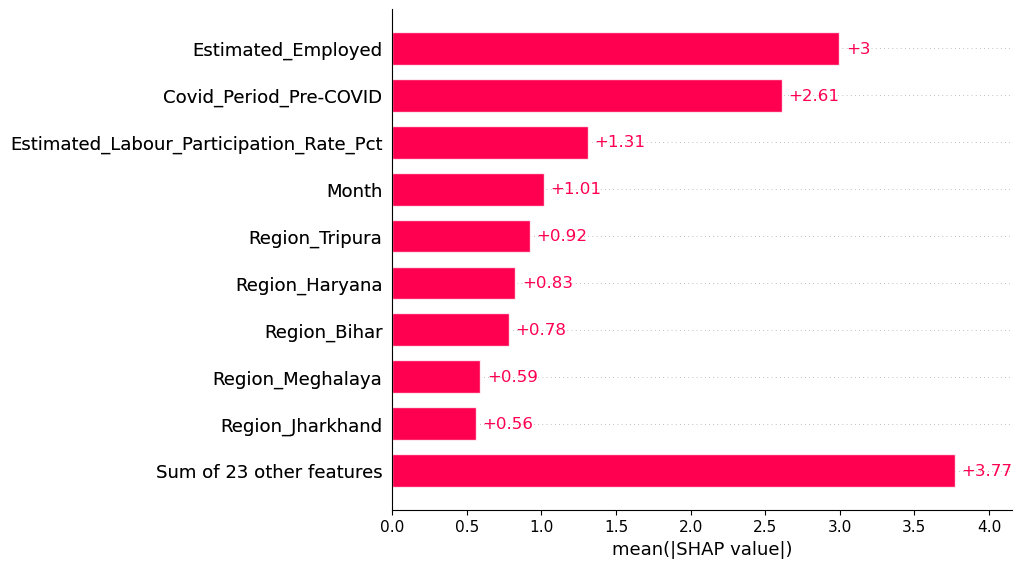

In [81]:
#Save SHAO Figures
plt.figure()
shap.plots.bar(
    shap_values,
    show=False
)
plt.savefig(
    "shap_bar.png",
    bbox_inches="tight"
)

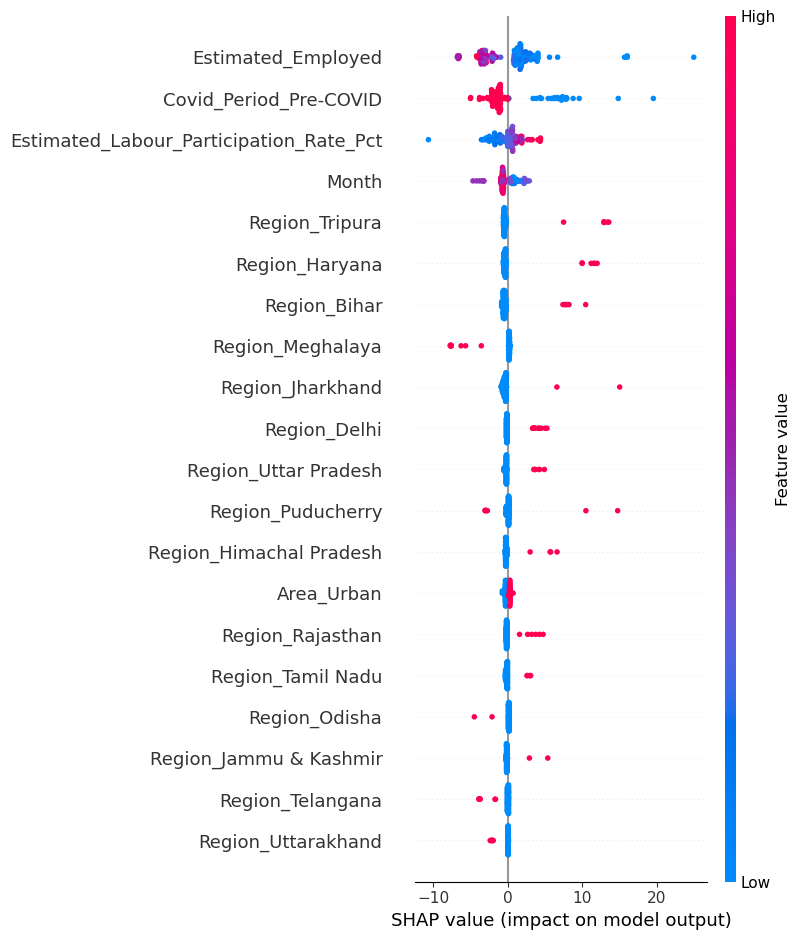

In [82]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "shap_summary.png",
    bbox_inches="tight"
)

In [83]:
# Comparison Table
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [3.85, 6.42, 0.72]
})

results

,Metric,Value
0,MAE,3.85
1,RMSE,6.42
2,R²,0.72


In [84]:
# save cleaned dataset
df.to_csv("unemployment_clean.csv", index=False)

In [88]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\hp\OneDrive\Desktop\Oasis infoby\Post-covid unemployment
['.ipynb_checkpoints', 'An Exploratory Analysis of Unemployment Trends During the COVID-19 Period in India.ipynb', 'data', 'Unemployment_Project']


# Create app.py
import streamlit as st
import pandas as pd
import plotly.express as px

# --------------------------------------------------
# PAGE CONFIG
# --------------------------------------------------

st.set_page_config(
    page_title="India Unemployment Dashboard",
    page_icon="📊",
    layout="wide"
)

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

@st.cache_data
def load_data():
    df = pd.read_csv("unemployment_clean.csv")
    df["Date"] = pd.to_datetime(df["Date"])
    return df

df = load_data()

# --------------------------------------------------
# TITLE
# --------------------------------------------------

st.title("📊 Unemployment Trends During COVID-19 in India")
st.markdown("""
### Exploratory Analysis and Explainable Machine Learning

This dashboard explores unemployment trends across India before and during COVID-19 using
statistical analysis, visualization, XGBoost and SHAP explainability.
""")

# --------------------------------------------------
# KPI SECTION
# --------------------------------------------------

pre_mean = df[df["Covid_Period"]=="Pre-COVID"]["Estimated_Unemployment_Rate_Pct"].mean()

covid_mean = df[df["Covid_Period"]=="COVID Period"]["Estimated_Unemployment_Rate_Pct"].mean()

increase = ((covid_mean-pre_mean)/pre_mean)*100

max_rate = df["Estimated_Unemployment_Rate_Pct"].max()

avg_rate = df["Estimated_Unemployment_Rate_Pct"].mean()

col1,col2,col3,col4 = st.columns(4)

col1.metric(
    "Average Unemployment",
    f"{avg_rate:.2f}%"
)

col2.metric(
    "Maximum Unemployment",
    f"{max_rate:.2f}%"
)

col3.metric(
    "Pre-COVID Mean",
    f"{pre_mean:.2f}%"
)

col4.metric(
    "COVID Increase",
    f"{increase:.1f}%"
)

st.divider()

# --------------------------------------------------
# NATIONAL TREND
# --------------------------------------------------

st.subheader("📈 National Unemployment Trend")

national_trend = (
    df.groupby("Date")
    ["Estimated_Unemployment_Rate_Pct"]
    .mean()
    .reset_index()
)

fig = px.line(
    national_trend,
    x="Date",
    y="Estimated_Unemployment_Rate_Pct",
    markers=True,
    title="National Average Unemployment Rate"
)

st.plotly_chart(fig,use_container_width=True)

# --------------------------------------------------
# URBAN VS RURAL
# --------------------------------------------------

st.subheader("🏙️ Urban vs Rural Comparison")

area_trend = (
    df.groupby(["Date","Area"])
    ["Estimated_Unemployment_Rate_Pct"]
    .mean()
    .reset_index()
)

fig = px.line(
    area_trend,
    x="Date",
    y="Estimated_Unemployment_Rate_Pct",
    color="Area",
    markers=True,
    title="Urban vs Rural Unemployment Trend"
)

st.plotly_chart(fig,use_container_width=True)

# --------------------------------------------------
# ZONE TREND
# --------------------------------------------------

st.subheader("🗺️ Zone-Level Unemployment Trend")

zone_trend = (
    df.groupby(["Date","zone"])
    ["Estimated_Unemployment_Rate_Pct"]
    .mean()
    .reset_index()
)

fig = px.line(
    zone_trend,
    x="Date",
    y="Estimated_Unemployment_Rate_Pct",
    color="zone",
    markers=True,
    title="Unemployment Trend by Zone"
)

st.plotly_chart(fig,use_container_width=True)

# --------------------------------------------------
# TOP REGIONS
# --------------------------------------------------

st.subheader("🏆 Top 10 Regions by Average Unemployment")

top_regions = (
    df.groupby("Region")
    ["Estimated_Unemployment_Rate_Pct"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_regions,
    x="Estimated_Unemployment_Rate_Pct",
    y="Region",
    orientation="h",
    text="Estimated_Unemployment_Rate_Pct",
    title="Top 10 Regions"
)

fig.update_layout(
    yaxis=dict(categoryorder="total ascending")
)

st.plotly_chart(fig,use_container_width=True)

# --------------------------------------------------
# MODEL PERFORMANCE
# --------------------------------------------------

st.subheader("🤖 XGBoost Model Performance")

results = pd.DataFrame({
    "Metric":["MAE","RMSE","R²"],
    "Value":[3.85,6.42,0.72]
})

st.dataframe(
    results,
    use_container_width=True
)

# --------------------------------------------------
# SHAP
# --------------------------------------------------

st.subheader("🔍 Explainable AI (SHAP)")

col1,col2 = st.columns(2)

with col1:
    st.image(
        "shap_bar.png",
        caption="Global Feature Importance"
    )

with col2:
    st.image(
        "shap_summary.png",
        caption="SHAP Summary Plot"
    )

# --------------------------------------------------
# FINDINGS
# --------------------------------------------------

st.subheader("📌 Key Findings")

st.markdown("""
### Main Insights

- COVID-19 increased average unemployment by approximately **110%**.
- The increase was statistically significant (**p < 0.001**).
- Urban areas experienced consistently higher unemployment than rural areas.
- Northern and Eastern regions showed the largest unemployment spikes.
- Tripura, Haryana, Jharkhand and Bihar were among the most affected regions.
- XGBoost explained approximately **72%** of unemployment variation.
- SHAP analysis identified employment level, COVID period and regional effects as the strongest drivers of unemployment.
""")

# --------------------------------------------------
# FOOTER
# --------------------------------------------------

st.divider()

st.caption(
    "Project: An Exploratory Analysis of Unemployment Trends During the COVID-19 Period in India | Oasis Infobyte Data Science Internship"
)

COVID-19 increased unemployment by approximately 110% in India.
Urban regions experienced greater unemployment pressure than rural regions.
Northern and Eastern regions were the most affected.
Employment level, geographic location, and COVID period were the strongest predictors of unemployment.